In [45]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [46]:
# Model / data parameters
num_classes = 10
input_shape = (32, 32, 3)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [47]:
# Create the model
inputs = keras.Input(shape=input_shape)
#
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
x = keras.layers.BatchNormalization() (x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = keras.layers.BatchNormalization() (x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu')(x)
x = keras.layers.BatchNormalization() (x)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu')(x)
x = keras.layers.BatchNormalization() (x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="CIFAR10_CNN")

model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 10, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,562 (592.04 KB)

 Trainable params: 151,242 (590.79 KB)

 Non-trainable params: 320 (1.25 KB)

In [48]:

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Monitors val_loss after every epoch
    patience=8, # If validation fails to improve after 10 epochs --> end
    restore_best_weights=True # Rolls back the epoch where fail occurred
)

In [49]:
batch_size = 32
epochs = 50

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks=[early_stopping])

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 225s 140ms/step - accuracy: 0.4116 - loss: 1.6489 - val_accuracy: 0.5142 - val_loss: 1.3916
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 198s 140ms/step - accuracy: 0.5536 - loss: 1.2586 - val_accuracy: 0.6190 - val_loss: 1.0701
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 206s 143ms/step - accuracy: 0.6187 - loss: 1.0842 - val_accuracy: 0.5546 - val_loss: 1.4103
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 197s 140ms/step - accuracy: 0.6523 - loss: 0.9895 - val_accuracy: 0.6982 - val_loss: 0.8447
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 196s 139ms/step - accuracy: 0.6814 - loss: 0.9152 - val_accuracy: 0.6768 - val_loss: 0.9486
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 196s 140ms/step - accuracy: 0.6968 - loss: 0.8644 - val_accuracy: 0.7304 - val_loss: 0.7646
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 188s 134ms/step - accuracy: 0.7127 - loss: 0.8231 - val_accuracy: 0.7326 - val_loss: 0.7639
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 163s 116ms/step - ac

In the plot we see that at epoch number 35 we have the lowest validation loss. After that it starts to overfit and at epoch 44 our callback triggers, because the validation loss has not decreased after 8 epochs. Epochs 35-44 are restored and the model settles at epoch 35.

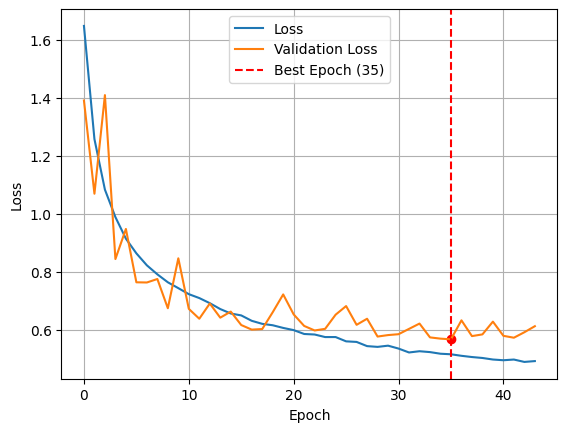

In [50]:
best_epoch = np.argmin(history.history["val_loss"])
best_val_loss = history.history["val_loss"][best_epoch]

plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f"Best Epoch ({best_epoch})")
plt.scatter(best_epoch, best_val_loss, color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

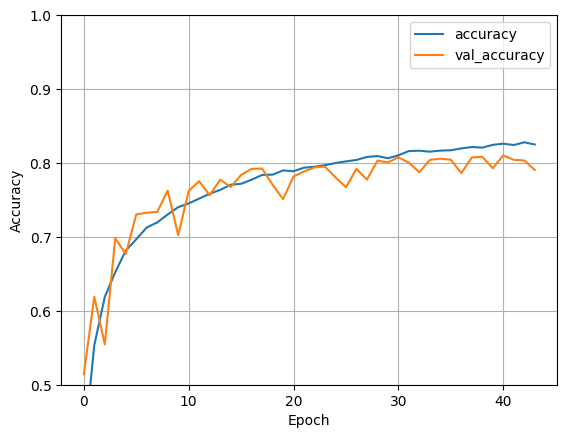

In [51]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5, 1])
plt.grid()
plt.legend()

In [52]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.5882046222686768
Test accuracy: 0.7983999848365784


## FCN ja CNN Cifar10 kuvaluokittelu -raportti

Kouluttamissamme malleissa tarkkuudet olivat FCN-mallille noin 55% ja CNN-mallille noin 80%.

FCN arkkitehtuuri on kehno algoritmi generalisoituvaan kuvien luokitteluun ja se näkyy tunnistustarkkuudessa. Pienetkin erot kuvien pikselilokaatioissa saa mallin hämmentymään, sillä neuronien painoarvot ovat lokaalisti määrittyneet. FCN on silti käytännöllinen tilanteisiin, joissa tiedetään sisääntulokuvien olevan samankaltaisia ja ennustettavia. Arkkitehtuurin yksinkertaisuus ja ymmärrettävyys ovat myös sen vahvuuksia.
 
CNN-malli on usein toimivampi kuvantunnistukseen. Malli kouluttaa pieniä filttereitä, jotka lopulta kuvastavat harjoitusdatassa olevia muotoja ja toisteellisia kuvioita, joita sitten voidaan käyttää arvioimaan minkä tahansa kuvien luokkia. Ensimmäinen kokeilumme CNN mallilla pääsi noin 70% tunnistustarkkuuteen. Tämän verkon rakenne oli simppeli ja piilokerroksia oli vain muutama. Seuraavassa iteraatiossa kokeilimme lisätä kerrosten määrää. Lisäsimme batch-normalisaatio-, konvoluutio-, dropout-, sekä max-pooling kerroksia. Nämä muutokset nostivat tarkkuuden noin 80:een prosentiin.

Kokeilimme myös mielenkiinnosta eri batch kokoja, mutta 16 ja 64 batch-size tuottivat kummatkin huonompia tarkkuuksia.